**Import Libraries**

In [1]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.ticker as mtick
import plotly.express as ex
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    fbeta_score, make_scorer
)
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeRegressor
from sklearn.base import BaseEstimator, TransformerMixin  
from imblearn.pipeline import Pipeline as ImbPipeline

%matplotlib inline
background_color = "#f6f6f6"
RANDOM_STATE = 42


**Load Dataset**

In [2]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.sample(5)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
3971,48244,Female,38.0,0,0,No,Private,Rural,77.50,36.9,smokes,0
3973,61757,Male,31.0,0,0,Yes,Self-employed,Rural,61.10,26.5,never smoked,0
2192,26084,Female,77.0,1,0,Yes,Self-employed,Urban,109.51,NaN,never smoked,0
62,65842,Female,67.0,1,0,Yes,Self-employed,Rural,61.94,25.3,smokes,1
4026,4383,Female,64.0,0,0,Yes,Govt_job,Urban,76.12,38.2,formerly smoked,0


**Check Dataset Size**

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5110
Number of columns: 12


**Display Columns and it data type**

In [4]:
df.dtypes

id                     int64
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object

**Explore data type with object have what atribute inside**

In [5]:
for column in df:
    if df[column].dtypes=='object':
        print(f'{column} : {df[column].unique()}')

we would like to clean up the 'Other' column , let see how many column contain gender == 'other'

In [6]:
other_rows = df[df['gender'] == 'Other']
print("Rows containing 'Other':")
print(other_rows)

Rows containing 'Other':
         id gender   age  hypertension  heart_disease ever_married work_type  \
3116  56156  Other  26.0             0              0           No   Private   

     Residence_type  avg_glucose_level   bmi   smoking_status  stroke  
3116          Rural             143.33  22.4  formerly smoked       0  


Well, only 1, so we will drop it

In [7]:
df.drop(df[df['gender'] == 'Other'].index, inplace=True)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5109
Number of columns: 12


**Check missing value**

In [8]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

**BMI Imputer as a Pipeline Step (fit on training data only, inside the pipeline)**


In [9]:
class BMIDecisionTreeImputer(BaseEstimator, TransformerMixin):


    def fit(self, X, y=None):
        X = X.copy()

        bmi_features = X[['age', 'gender']]
        bmi_target = X['bmi']

        # Only use rows with known BMI
        mask = bmi_target.notna()

        self.bmi_model = Pipeline([
            ('scale', StandardScaler()),
            ('tree', DecisionTreeRegressor(random_state=RANDOM_STATE))
        ])

        self.bmi_model.fit(
            bmi_features.loc[mask],
            bmi_target.loc[mask]
        )

        return self

    def transform(self, X):
        X = X.copy()

        missing_mask = X['bmi'].isna()

        if missing_mask.any():
            predicted_bmi = self.bmi_model.predict(
                X.loc[missing_mask, ['age', 'gender']]
            )
            X.loc[missing_mask, 'bmi'] = predicted_bmi

        return X


In [10]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

**Check Duplicate Data**

In [11]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


# Explore Data Analysis

In [12]:
fig = ex.pie(df, names='stroke', color_discrete_sequence=['#17BECF', '#FFC20A'])
fig.update_layout(title='<b>Proportion Of Stroke Samples<b>')
fig.show()


we can clearly see the dataset is unbalanced, so we will oversample it using the SMOTE approach later, before training the Random Forest model

**Age Distribution**

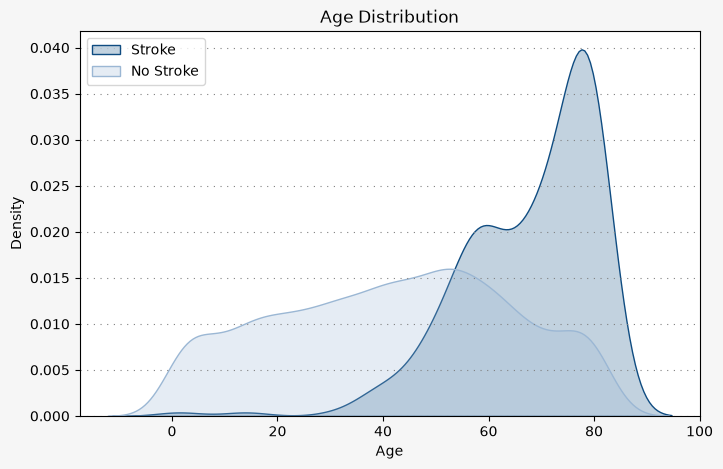

In [13]:
str_only = df[df['stroke'] == 1]
no_str_only = df[df['stroke'] == 0]

fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

ax.grid(color='gray', linestyle=':', axis='y', dashes=(1,5))

positive = pd.DataFrame(str_only["age"])
negative = pd.DataFrame(no_str_only["age"])

sns.kdeplot(positive["age"], ax=ax, color="#0f4c81", fill=True, label="Stroke")
sns.kdeplot(negative["age"], ax=ax, color="#9bb7d4", fill=True, label="No Stroke")

ax.set_title("Age Distribution")
ax.set_xlabel("Age")
ax.set_ylabel("Density")
ax.legend()

plt.show()


**Smoking Status**

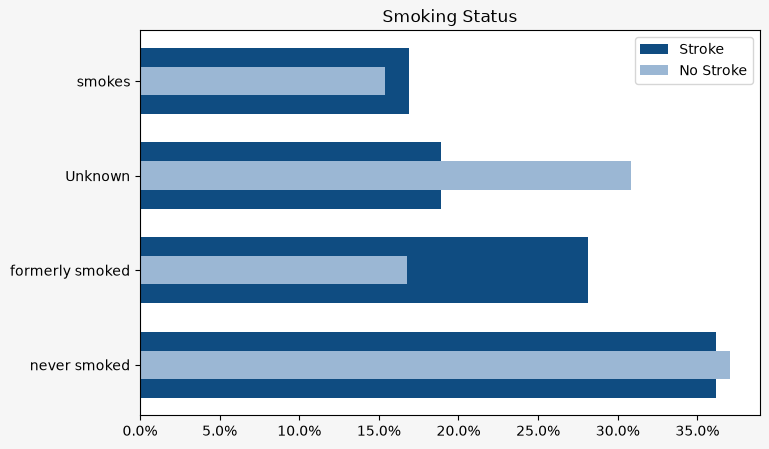

In [14]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

positive = pd.DataFrame(str_only["smoking_status"].value_counts())
positive["Percentage"] = (positive["count"] / positive["count"].sum()) * 100

negative = pd.DataFrame(no_str_only["smoking_status"].value_counts())
negative["Percentage"] = (negative["count"] / negative["count"].sum()) * 100

ax.barh(positive.index, positive["Percentage"], color="#0f4c81", height=0.7, label="Stroke")
ax.barh(negative.index, negative["Percentage"], color="#9bb7d4", height=0.3, label="No Stroke")

ax.set_title("Smoking Status")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()

plt.show()


**Gender**

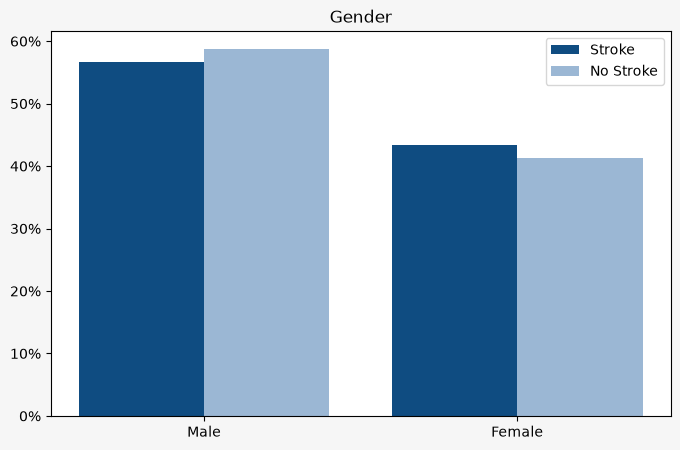

In [15]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

positive = pd.DataFrame(str_only["gender"].value_counts())
positive["Percentage"] = positive["count"] / positive["count"].sum() * 100

negative = pd.DataFrame(no_str_only["gender"].value_counts())
negative["Percentage"] = negative["count"] / negative["count"].sum() * 100

x = np.arange(len(positive))

ax.bar(x, positive["Percentage"], width=0.4, color="#0f4c81", label="Stroke")
ax.bar(x+0.4, negative["Percentage"], width=0.4, color="#9bb7d4", label="No Stroke")

ax.set_xticks(x+0.2)
ax.set_xticklabels(["Male","Female"])
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Gender")
ax.legend()

plt.show()

**Heart Disease**

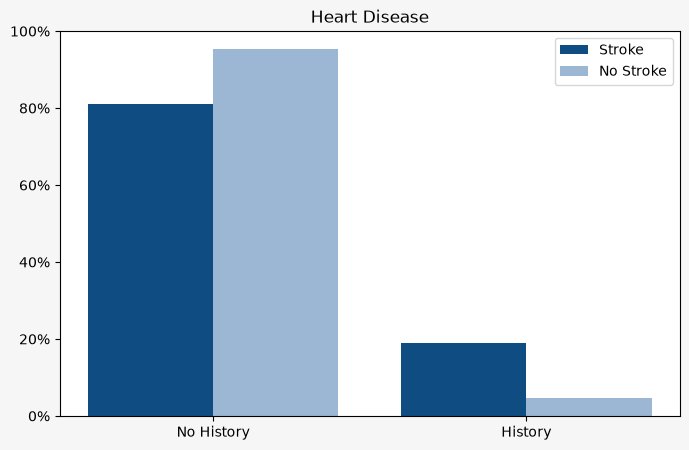

In [16]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

positive = pd.DataFrame(str_only["heart_disease"].value_counts())
positive["Percentage"] = positive["count"] / positive["count"].sum() * 100

negative = pd.DataFrame(no_str_only["heart_disease"].value_counts())
negative["Percentage"] = negative["count"] / negative["count"].sum() * 100

x = np.arange(len(positive))

ax.bar(x, positive["Percentage"], width=0.4, color="#0f4c81", label="Stroke")
ax.bar(x+0.4, negative["Percentage"], width=0.4, color="#9bb7d4", label="No Stroke")

ax.set_xticks(x+0.2)
ax.set_xticklabels(["No History","History"])
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Heart Disease")
ax.legend()

plt.show()


**Average Glucose Level**

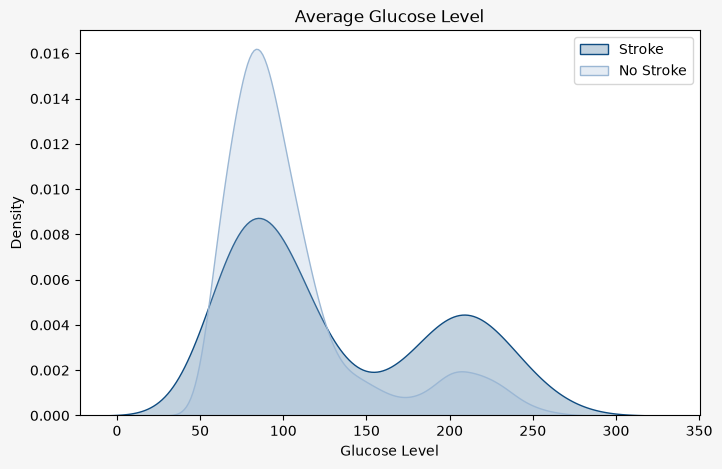

In [17]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

sns.kdeplot(str_only["avg_glucose_level"], fill=True, color="#0f4c81", label="Stroke")
sns.kdeplot(no_str_only["avg_glucose_level"], fill=True, color="#9bb7d4", label="No Stroke")

ax.set_title("Average Glucose Level")
ax.set_xlabel("Glucose Level")
ax.legend()

plt.show()


**BMI**

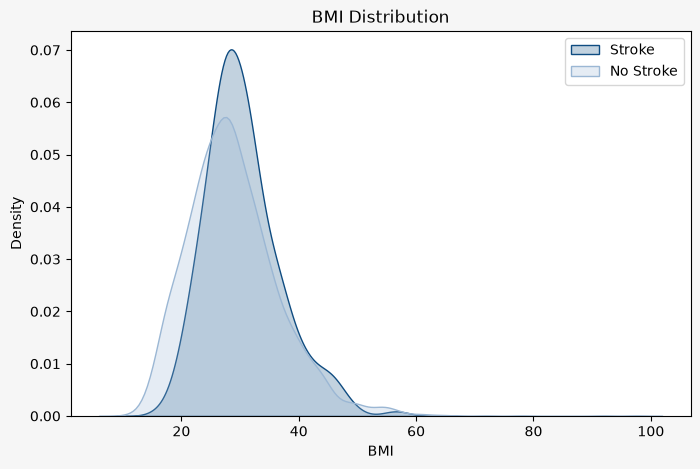

In [18]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

sns.kdeplot(str_only["bmi"], fill=True, color="#0f4c81", label="Stroke")
sns.kdeplot(no_str_only["bmi"], fill=True, color="#9bb7d4", label="No Stroke")

ax.set_title("BMI Distribution")
ax.set_xlabel("BMI")
ax.legend()

plt.show()


**Work Type**

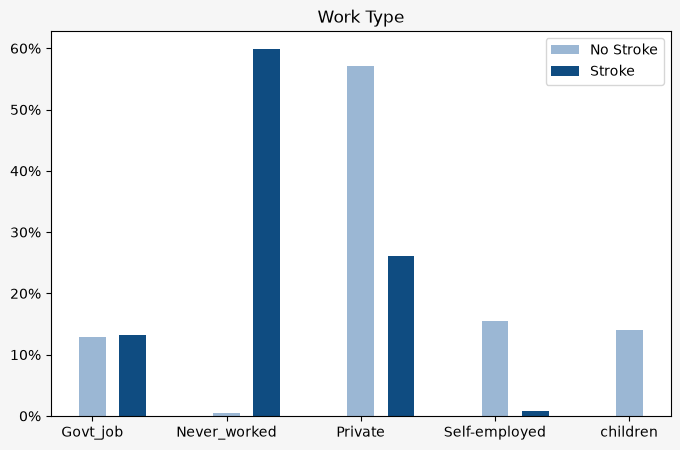

In [19]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

positive = pd.DataFrame(str_only["work_type"].value_counts()).sort_index()
positive["Percentage"] = positive["count"] / positive["count"].sum() * 100

negative = pd.DataFrame(no_str_only["work_type"].value_counts()).sort_index()
negative["Percentage"] = negative["count"] / negative["count"].sum() * 100

ax.bar(negative.index, negative["Percentage"], width=0.2, color="#9bb7d4", label="No Stroke")
ax.bar(np.arange(len(positive))+0.3, positive["Percentage"], width=0.2, color="#0f4c81", label="Stroke")

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Work Type")
ax.legend()

plt.show()


**Hypertension**

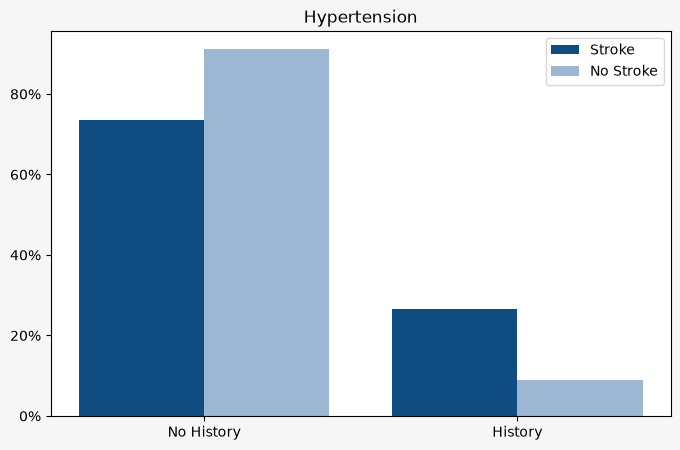

In [20]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

positive = pd.DataFrame(str_only["hypertension"].value_counts())
positive["Percentage"] = positive["count"] / positive["count"].sum() * 100

negative = pd.DataFrame(no_str_only["hypertension"].value_counts())
negative["Percentage"] = negative["count"] / negative["count"].sum() * 100

x = np.arange(len(positive))

ax.bar(x, positive["Percentage"], width=0.4, color="#0f4c81", label="Stroke")
ax.bar(x+0.4, negative["Percentage"], width=0.4, color="#9bb7d4", label="No Stroke")

ax.set_xticks(x+0.2)
ax.set_xticklabels(["No History","History"])
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Hypertension")
ax.legend()

plt.show()


**Remove ID Column**

The id column is only a patient identifier.
It does not represent a meaningful health characteristic.

In [21]:
df = df.drop('id', axis=1)
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


**Find unique data in each column**

In [22]:
for column in df:
    if df[column].dtypes=='object':
        print(f'{column} : {df[column].unique()}')


# Label Encoding

**ever_married**

In [23]:
df['ever_married'] = df['ever_married'].replace({'Yes': 1, 'No': 0})

In [24]:
print(f"ever_married : {df['ever_married'].unique()}")

ever_married : [1 0]


**convert into integer**

In [25]:
df['ever_married'] = pd.to_numeric(df['ever_married'])

**gender**

In [26]:
df['gender'] = df['gender'].replace({'Male': 1, 'Female': 0})

In [27]:
print(f"gender : {df['gender'].unique()}")

gender : [1 0]


**convert into integer**

In [28]:
df['gender'] = pd.to_numeric(df['gender'])

# One Hot Encoding

In [29]:
for column in df:
    if df[column].dtypes=='object':
        print(f'{column} : {df[column].unique()}')

**now we will use one hot encoding for work type, resident type and smoking status**

In [30]:
df=pd.get_dummies(data=df,columns=['work_type','Residence_type','smoking_status'])
df.sample(5)

,gender,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
1322,0,55.0,1,0,1,206.40,54.8,0,False,False,True,False,False,False,True,False,False,True,False
443,1,20.0,0,0,0,98.70,26.2,0,True,False,False,False,False,True,False,True,False,False,False
1056,1,9.0,0,0,0,97.84,23.3,0,False,False,False,False,True,False,True,True,False,False,False
3138,0,54.0,0,0,1,81.26,26.5,0,False,False,True,False,False,True,False,True,False,False,False
288,0,17.0,0,0,0,82.18,23.4,0,False,False,False,True,False,False,True,True,False,False,False


In [31]:
df.dtypes

gender                              int64
age                               float64
hypertension                        int64
heart_disease                       int64
ever_married                        int64
avg_glucose_level                 float64
bmi                               float64
stroke                              int64
work_type_Govt_job                   bool
work_type_Never_worked               bool
work_type_Private                    bool
work_type_Self-employed              bool
work_type_children                   bool
Residence_type_Rural                 bool
Residence_type_Urban                 bool
smoking_status_Unknown               bool
smoking_status_formerly smoked       bool
smoking_status_never smoked          bool
smoking_status_smokes                bool
dtype: object

In [32]:
# 1. Prepare features/target 
X = df.drop('stroke', axis='columns')
y = df['stroke']

# 2. Train/test split FIRST
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)


X_train.shape, X_test.shape


((4087, 18), (1022, 18))

# Baseline Model: Random Forest without SMOTE

Training Baseline Random Forest (Without SMOTE)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters for Baseline RF: {'rf__n_estimators': 200, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 1, 'rf__max_depth': None}

BASELINE MODEL EVALUATION (NO SMOTE)
Accuracy : 0.9511
Precision: 0.5000
Recall   : 0.0200
F1 Score : 0.0385
F2 Score  : 0.0248
ROC-AUC  : 0.8028


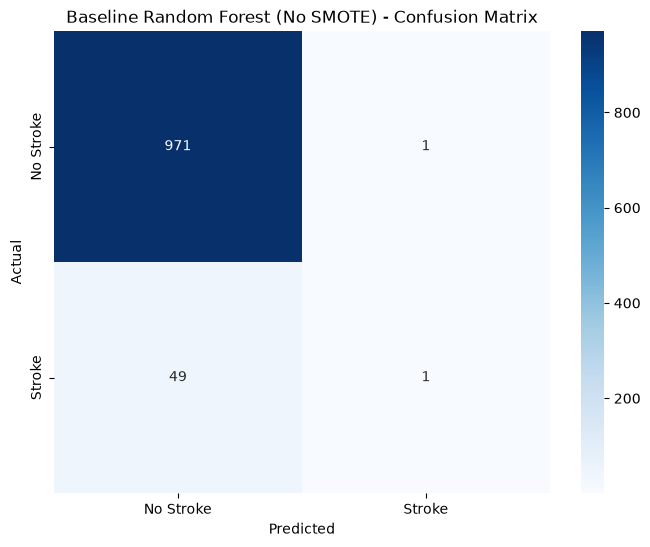

In [33]:
print("Training Baseline Random Forest (Without SMOTE)...")

# 1. Wrap in a pipeline so bmi_imputer is refit fresh on each CV fold's training portion --
baseline_pipeline = Pipeline(steps=[
    ('bmi_imputer', BMIDecisionTreeImputer()),
    ('rf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

# 2. Define Hyperparameter grid 
param_distributions_base = {
    'rf__n_estimators': [100, 200, 300, 400],
    'rf__max_depth': [5, 8, 12, 15, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
}

# 3. Setup RandomizedSearchCV
rf_base_search = RandomizedSearchCV(
    estimator=baseline_pipeline,
    param_distributions=param_distributions_base,
    n_iter=20,
    cv=5,
    scoring='recall', 
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

# 4. Fit directly on the IMBALANCED, raw (unscaled, BMI-missing) training data 
rf_base_search.fit(X_train, y_train)
best_rf_base = rf_base_search.best_estimator_

# 5. Evaluate on the Unseen Test Data
y_pred_base = best_rf_base.predict(X_test)
y_pred_proba_base = best_rf_base.predict_proba(X_test)[:, 1]

print("\nBest parameters for Baseline RF:", rf_base_search.best_params_)
print("\n" + "=" * 60)
print("BASELINE MODEL EVALUATION (NO SMOTE)")
print("=" * 60)
print(f"Accuracy : {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_base):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_base):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_base):.4f}")
print(f"F2 Score  : {fbeta_score(y_test, y_pred_base, beta=2):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_pred_proba_base):.4f}")

# 6. Confusion Matrix Visualization
cm_base = confusion_matrix(y_test, y_pred_base)
plt.figure(figsize=(8,6))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Stroke', 'Stroke'],
            yticklabels=['No Stroke', 'Stroke'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Baseline Random Forest (No SMOTE) - Confusion Matrix")
plt.show()


# Handling Imbalance with SMOTE

SMOTE is applied strictly to the **scaled training data** — the test set stays untouched and still reflects the
real-world 90/10 imbalance, so evaluation metrics are meaningful.

In [34]:
print("Class distribution BEFORE SMOTE:")
print(y_train.value_counts())

X_train_imputed_demo = best_rf_base.named_steps['bmi_imputer'].transform(X_train)

smote = SMOTE(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_imputed_demo, y_train)

print("\nClass distribution AFTER SMOTE:")
print(y_train_resampled.value_counts())


Class distribution BEFORE SMOTE:
stroke
0    3888
1     199
Name: count, dtype: int64

Class distribution AFTER SMOTE:
stroke
0    3888
1    3888
Name: count, dtype: int64


# Random Forest (with SMOTE)

In [35]:
# 1. Create a pipeline with BMI imputation, SMOTE and Random Forest
pipeline = ImbPipeline(steps=[
    ('bmi_imputer', BMIDecisionTreeImputer()),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('rf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

# 2. Define the grid of hyperparameters
param_distributions = {
    'rf__n_estimators': [100, 200, 300, 400],
    'rf__max_depth': [5, 8, 12, 15, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__class_weight': [None, 'balanced', 'balanced_subsample']
}

f2_scorer = make_scorer(fbeta_score, beta=2)

# 3. Set up the random search using the pipeline
rf_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    cv=5,
    scoring=f2_scorer,  
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

# 4. Fit the search on the RAW (unscaled, BMI-missing) training data
print("Tuning hyperparameters... this might take a minute.")
rf_search.fit(X_train, y_train)

# 5. Keep the FULL fitted pipeline as the model going forward.
best_pipeline = rf_search.best_estimator_
rf_model = best_pipeline.named_steps['rf']
print(f"\nBest parameters found:\n{rf_search.best_params_}")


# 1. Get the raw probabilities for the stroke class (Class 1)
y_pred_proba = best_pipeline.predict_proba(X_test)[:, 1]

# 2. Set a custom threshold
custom_threshold = 0.50

# 3. Create new predictions based on this threshold
y_pred_threshold = (y_pred_proba >= custom_threshold).astype(int)

print(f"\nNew Recall: {recall_score(y_test, y_pred_threshold):.4f}")

# 4. Overwrite y_pred so the rest of the notebook uses these new results
y_pred = y_pred_threshold


Tuning hyperparameters... this might take a minute.
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters found:
{'rf__n_estimators': 400, 'rf__min_samples_split': 10, 'rf__min_samples_leaf': 2, 'rf__max_depth': 5, 'rf__class_weight': 'balanced_subsample'}

New Recall: 0.6600


In [36]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.8023483365949119


In [37]:
y_pred[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1])

In [38]:
y_test[:20]

3667    0
2217    0
374     0
2392    0
299     0
511     0
716     0
741     0
2377    0
1451    0
3121    0
4663    0
5061    0
1312    0
3098    0
1262    0
3185    0
378     0
1709    0
2275    0
Name: stroke, dtype: int64

In [39]:
print(classification_report(y_test, y_pred, target_names=['No Stroke','Stroke']))

              precision    recall  f1-score   support

   No Stroke       0.98      0.81      0.89       972
      Stroke       0.15      0.66      0.25        50

    accuracy                           0.80      1022
   macro avg       0.57      0.73      0.57      1022
weighted avg       0.94      0.80      0.85      1022



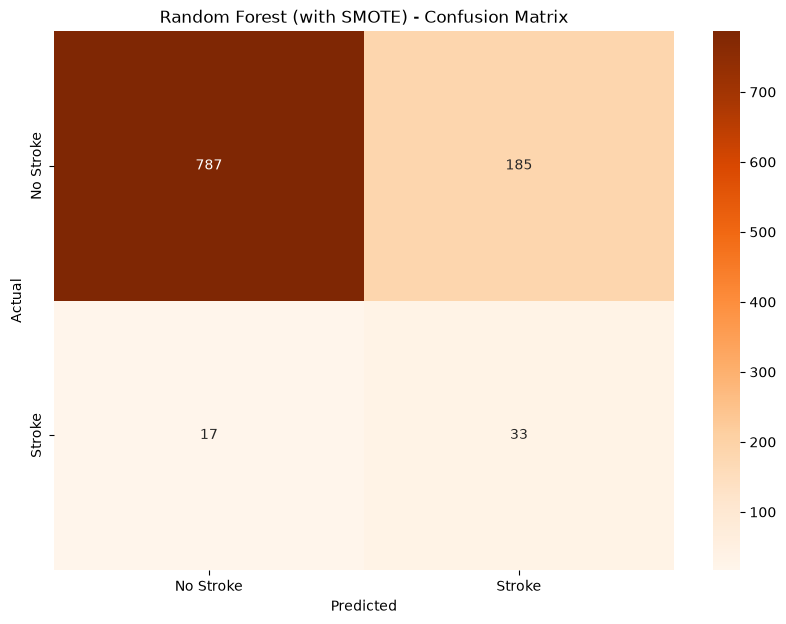

In [40]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Stroke','Stroke'], yticklabels=['No Stroke','Stroke'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest (with SMOTE) - Confusion Matrix')
plt.show()


**Full Evaluation Metrics**

In [41]:
print("=" * 60)
print("MODEL EVALUATION ON UNSEEN TEST DATA (WITH SMOTE)")
print("=" * 60)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"F2 Score : {fbeta_score(y_test, y_pred, beta=2):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_pred_proba):.4f}")


MODEL EVALUATION ON UNSEEN TEST DATA (WITH SMOTE)
Accuracy : 0.8023
Precision: 0.1514
Recall   : 0.6600
F1 Score : 0.2463
F2 Score : 0.3947
ROC-AUC  : 0.7929


**Feature Importance**

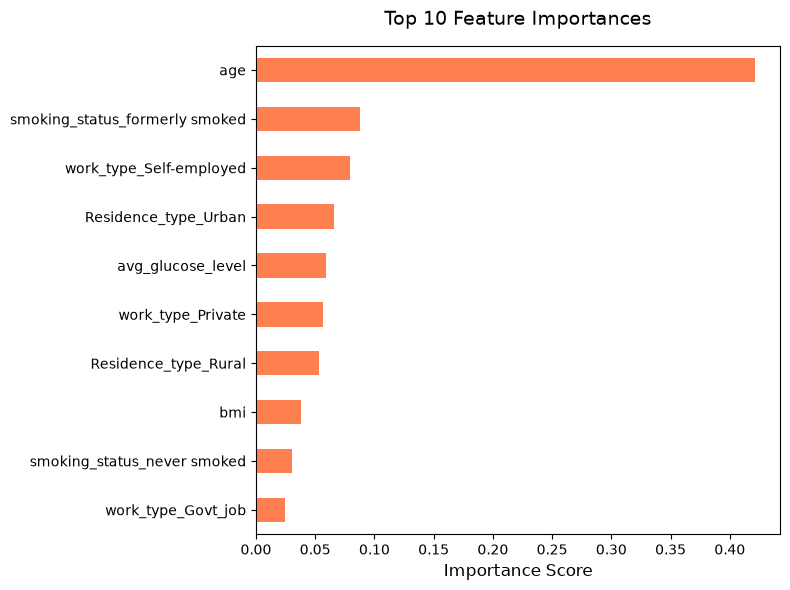

In [42]:
plt.figure(figsize=(8, 6))
feature_importance = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=True)

feature_importance.tail(10).plot(kind='barh', color='coral')
plt.title('Top 10 Feature Importances', pad=15, fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.show()


**ROC Curve**

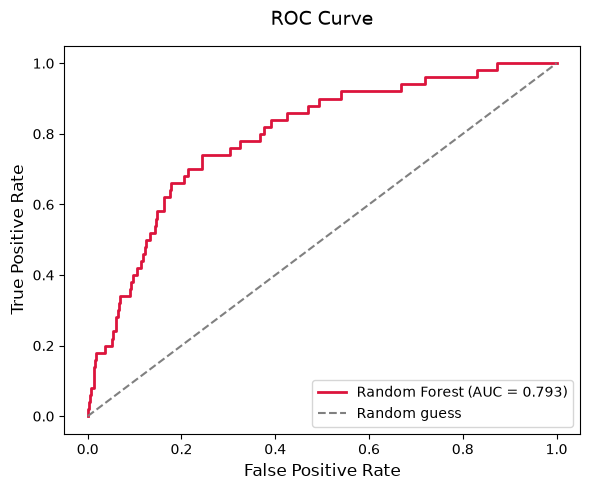

In [43]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.3f})", color="crimson", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.title("ROC Curve", pad=15, fontsize=14)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [44]:
joblib.dump(best_pipeline, 'stroke_rf_model.pkl')

fitted_bmi_imputer = best_pipeline.named_steps['bmi_imputer']
X_train_display = fitted_bmi_imputer.transform(X_train)
columns_to_scale = ['age', 'avg_glucose_level', 'bmi']
scaler = MinMaxScaler()
scaler.fit(X_train_display[columns_to_scale])
joblib.dump(scaler, 'rf_scaler.pkl')

joblib.dump(list(X.columns), 'rf_columns.pkl')

print("Files saved successfully! Ready for Streamlit.")


Files saved successfully! Ready for Streamlit.
